In [1]:
import h5py
import numpy as np
import pandas as pd
import os
import datetime
import time
from make_dashboard import make_dashboard
from belt.evaluate import default_belt_merit
from belt.belt_impact import run_belt, evaluate_belt
import json
from belt.tools import NpEncoder
import matplotlib.pyplot as plt

def convertToDatedFormat(destionation_folder):
    curr_date = datetime.date.today()
    year,month,day = curr_date.strftime('%Y'),curr_date.strftime('%m'),curr_date.strftime('%d')
    destionation_folder_dated = destionation_folder + "/" + year + "/" + month + "/" + day

    if not os.path.exists(destionation_folder_dated):
        os.makedirs(destionation_folder_dated)
    
    return destionation_folder_dated



In [2]:
prefix = './snapshot/2025/04/05/LCLSII-snapshot-2025-04-05T13:25:53-07:00'
#prefix = './snapshot/2025/05/17/LCLSII-snapshot-2025-05-17T10:15:01-07:00'
#prefix = './snapshot/2025/05/17/LCLSII-snapshot-2025-05-17T10:12:06-07:00'
#prefix = './snapshot/2025/05/17/LCLSII-snapshot-2025-05-17T10:10:39-07:00'
#prefix = './snapshot/2025/05/17/LCLSII-snapshot-2025-05-17T09:52:23-07:00' #input_beam =  "/sdf/data/ad/ard/u/jytang/lume-belt-live/STCAV_data/particle-2025-05-17-chirped.h5.h5"
#prefix = './snapshot/2025/09/25/LCLSII-snapshot-2025-09-25T10:07:11-07:00'

phase_shift = 1.5
#input_beam = "/sdf/data/ad/ard/u/jytang/lume-belt-live/STCAV_data/particle-2025-05-17.h5"
#final_beam = "XTCAV_data/sim/LCLSII-snapshot-2025-05-17T09:52:23-07:00.h5"

#input_beam = '/sdf/data/ad/ard/u/jytang/lume-belt-live/impact_particles/halo_final_particles.h5'
input_beam = '/sdf/data/ad/ard/u/jytang/lume-belt-live/STCAV_data/particle-2025-04-05.h5'

with h5py.File(prefix + '.h5', 'r') as f:
    pv_dic = {}
    for key in f.keys():
        pv_dic[key] = np.array(f[key]).item()

/lscratch/jytang/tmp/ipykernel_3791622/1585831157.py:18: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  pv_dic[key] = np.array(f[key]).item()


In [3]:
pv_dic

{'ACCL:L1B:0200:AL:BETA': -27.428106270241198,
 'ACCL:L1B:0200:AL:CACT': -120.85156942056479,
 'ACCL:L1B:0200:AL:CO_AMPL': 102.14288850330328,
 'ACCL:L1B:0200:AL:EACT': 165.7066198313936,
 'ACCL:L1B:0200:AL:NEG_AMPL': 69.89760260596526,
 'ACCL:L1B:0200:AL:NOTA_AMPL': 51.227107137393965,
 'ACCL:L1B:0200:AL:NOTA_PHASE': 9.664222637352795,
 'ACCL:L1B:0200:AL:POS_AMPL': 82.31531991154716,
 'ACCL:L2B:0400:AL:BETA': -13.065831431071418,
 'ACCL:L2B:0400:AL:CACT': -300.2252633204669,
 'ACCL:L2B:0400:AL:EACT': 1293.363790060108,
 'ACCL:L3B:1600:AL:BETA': 0.0,
 'ACCL:L3B:1600:AL:CACT': -0.008696319892528948,
 'ACCL:L3B:1600:AL:EACT': 2212.1484877019147,
 'BEND:BC1B:200:BACT': 0.7938775258719654,
 'BEND:BC1B:400:BACT': 0.789974917874734,
 'BEND:BC1B:600:BACT': 0.7899756433159372,
 'BEND:BC1B:800:BACT': 0.7899828416635467,
 'BEND:BC2B:200:BACT': 2.343160360464855,
 'BEND:BC2B:500:BACT': 2.3431481683976143,
 'BEND:BC2B:600:BACT': 2.3431572272879966,
 'BEND:BC2B:900:BACT': 2.343157042543331,
 'PHYS:

In [4]:
CSV = 'pv_mapping/lclsii_belt.csv'
DF = pd.read_csv(CSV)#.dropna()

PVLIST = list(DF['device_pv_name'].dropna()) 


DF

,Variable,device_pv_name,pv_unit
0,Charge,BPMS:GUNB:314:TMIT,n_elecrons
1,Initial_energy,ACCL:L0B:0100:AACTMEANSUM,MV
2,L1B_energy,ACCL:L1B:0200:AL:EACT,MV
3,L1B_amp1,ACCL:L1B:0200:AL:CO_AMPL,MV
4,L1B_amp2,ACCL:L1B:0200:AL:NEG_AMPL,MV
5,L1B_amp3,ACCL:L1B:0200:AL:POS_AMPL,MV
6,L1B_chirp,ACCL:L1B:0200:AL:CACT,MV
7,L1B_phase,ACCL:L1B:0200:AL:BETA,deg
8,HL_amplitude,ACCL:L1B:0200:AL:NOTA_AMPL,MV
9,HL_phase,ACCL:L1B:0200:AL:NOTA_PHASE,deg


In [5]:
df = DF[DF['device_pv_name'].notna()]
assert len(df) > 0, 'Empty dataframe!'
    
pv_names = list(df['device_pv_name'])
df['pv_value'] = [pv_dic[k] for k in pv_names]

KeyError: 'BPMS:GUNB:314:TMIT'

In [ ]:
df

In [ ]:
settings = {"Impact_particles": input_beam, "num_doublings" : 4}
#settings = {"Impact_particles": "/sdf/data/ad/ard/u/jytang/lume-belt-live/STCAV_data/particle-2025-05-17-chirped.h5"}

#settings = {}
#settings = {"Impact_particles": "/sdf/data/ad/ard/u/jytang/lume-belt-live/impact_particles/final_particles_50pC_12072024.h5", "num_doublings": 7}



HL_phase = df.loc[df["Variable"] == "HL_phase", 'pv_value' ].values[0] - 180
HL_amplitude = df.loc[df["Variable"] == "HL_amplitude", 'pv_value' ].values[0]*1e6
HL_gradient = HL_amplitude/5.5346304

#HL_phase = df.loc[df["Variable"] == "HL_phase_2", 'pv_value' ].values[0]
#HL_amplitude = (df.loc[df["Variable"] == "HL_amplitude_chirponly", 'pv_value' ].values[0] +
#                    df.loc[df["Variable"] == "HL_amplitude_+FBK", 'pv_value' ].values[0] +
#                    df.loc[df["Variable"] == "HL_amplitude_-FBK", 'pv_value' ].values[0] )*1e6
#HL_gradient = HL_amplitude/5.5346304

L1_energy = df.loc[df["Variable"] == "L1B_energy", 'pv_value' ].values[0]
L1_chirp = df.loc[df["Variable"] == "L1B_chirp", 'pv_value' ].values[0]

L1_phase = df.loc[df["Variable"] == "L1B_phase", 'pv_value' ].values[0] 
L1_amplitude = (df.loc[df["Variable"] == "L1B_amp1", 'pv_value' ].values[0] + 
                    df.loc[df["Variable"] == "L1B_amp2", 'pv_value' ].values[0] +
                    df.loc[df["Variable"] == "L1B_amp3", 'pv_value' ].values[0])*1e6
L1_gradient = L1_amplitude/16.603888
                    
    #L1_amplitude = np.abs((L1_energy - HL_energy)/ np.cos(L1_phase/180*np.pi)*1e6/16.603888)
    #L1_amplitude = np.abs((L1_energy - HL_energy)*1e6/16.603888)



L2_energy = df.loc[df["Variable"] == "L2B_energy", 'pv_value' ].values[0]
L2_chirp = df.loc[df["Variable"] == "L2B_chirp", 'pv_value' ].values[0]

L2_phase = df.loc[df["Variable"] == "L2B_phase", 'pv_value' ].values[0]  
L2_gradient = np.abs(L2_energy/np.cos(L2_phase/180*np.pi)*1e6/99.623328)
    
    

L3_energy = df.loc[df["Variable"] == "L3B_energy", 'pv_value' ].values[0]
L3_chirp = df.loc[df["Variable"] == "L3B_chirp", 'pv_value' ].values[0]

L3_phase = df.loc[df["Variable"] == "L3B_phase", 'pv_value' ].values[0]
L3_gradient = np.abs(L3_energy/np.cos(L3_phase/180*np.pi)*1e6/166.038878)
    #L3_amplitude = np.abs(L3_energy*1e6/166.038878)
    
    
BC1_energy = df.loc[df["Variable"] == "BC1_energy", 'pv_value' ].values[0]/1e3
#BC1_energy = 0.25


#BC1_rigidity = (df.loc[df["Variable"] == "BCX11", 'pv_value' ].values[0] + df.loc[df["Variable"] == "BCX12", 'pv_value' ].values[0] +
#             df.loc[df["Variable"] == "BCX13", 'pv_value' ].values[0] + df.loc[df["Variable"] == "BCX14", 'pv_value' ].values[0])/4/10


BC1_rigidity = df.loc[df["Variable"] == "BCX11", 'pv_value' ].values[0] /10
BC1_angle = BC1_rigidity/(3.3356*BC1_energy)

BC2_energy = df.loc[df["Variable"] == "BC2_energy", 'pv_value' ].values[0]/1e3
#BC2_rigidity = (df.loc[df["Variable"] == "BCX21", 'pv_value' ].values[0] + df.loc[df["Variable"] == "BCX22", 'pv_value' ].values[0] +
#             df.loc[df["Variable"] == "BCX23", 'pv_value' ].values[0] + df.loc[df["Variable"] == "BCX24", 'pv_value' ].values[0])/4/10


BC2_rigidity = df.loc[df["Variable"] == "BCX21", 'pv_value' ].values[0]/10


BC2_angle = BC2_rigidity/(3.3356*BC2_energy)


BC1_energy_increment =BC1_energy*1e9 - (75e6 + L1_amplitude*np.cos(L1_phase/180*np.pi) +  HL_amplitude*np.cos(HL_phase/180*np.pi))
    #BC1_energy_increment =BC1_energy*1e9 - (90e6 + L1_energy*1e6 )
BC2_energy_increment = BC2_energy*1e9 - (BC1_energy*1e9 + L2_energy*1e6)

settings["BC1:angle"] = BC1_angle
settings["BC2:angle"] = BC2_angle
settings["L1:gradient"] = L1_gradient
settings["L1:phase_deg"] = L1_phase + phase_shift   #+1.15
settings["L2:gradient"] = L2_gradient 
settings["L2:phase_deg"] = L2_phase + phase_shift#+2
settings["L3:gradient"] = L3_gradient
settings["L3:phase_deg"] = L3_phase 
settings["HL:gradient"] = HL_gradient
settings["HL:phase_deg"] = HL_phase 

settings["EBC1:energy_increment"] = BC1_energy_increment
settings["EBC2:energy_increment"] = BC2_energy_increment

In [7]:
settings

NameError: name 'settings' is not defined

In [6]:
HL_phase = df.loc[df["Variable"] == "HL_phase", 'pv_value' ].values[0] - 180
HL_amplitude = df.loc[df["Variable"] == "HL_amplitude", 'pv_value' ].values[0]*1e6
HL_gradient = HL_amplitude/5.5346304

print(HL_phase)
print(HL_amplitude)

KeyError: 'pv_value'

In [241]:
HL_phase = df.loc[df["Variable"] == "HL_phase_2", 'pv_value' ].values[0]
HL_amplitude = (df.loc[df["Variable"] == "HL_amplitude_chirponly", 'pv_value' ].values[0] +
                    df.loc[df["Variable"] == "HL_amplitude_+FBK", 'pv_value' ].values[0] +
                    df.loc[df["Variable"] == "HL_amplitude_-FBK", 'pv_value' ].values[0] )*1e6
HL_gradient = HL_amplitude/5.5346304

print(HL_phase)
print(HL_amplitude)


-170.6049488876298
55417503.576130204


In [242]:
settings

{'Impact_particles': '/sdf/data/ad/ard/u/jytang/lume-belt-live/impact_particles/halo_final_particles.h5',
 'num_doublings': 4,
 'BC1:angle': np.float64(0.10126552618118735),
 'BC2:angle': np.float64(0.04707484982024845),
 'L1:gradient': np.float64(15499931.178800583),
 'L1:phase_deg': np.float64(-21.232918754213436),
 'L2:gradient': np.float64(14570911.2811576),
 'L2:phase_deg': np.float64(-19.79393453318126),
 'L3:gradient': np.float64(13605550.62693177),
 'L3:phase_deg': np.float64(0.0),
 'HL:gradient': np.float64(9759299.337502932),
 'HL:phase_deg': np.float64(-170.5492348199027),
 'EBC1:energy_increment': np.float64(-24059429.589547127),
 'EBC2:energy_increment': np.float64(-44539818.85424209)}

In [243]:
BC1_angle

np.float64(0.10126552618118735)

In [244]:
BC1_angle**2*(2.44781923989 + 2/3*0.203558243263)*2

np.float64(0.052986577306674866)

In [245]:
0.04682854110733011**2*(9.86910678674+ +2/3*0.549165215621)*2

0.044889865427122796

In [246]:
BC1_energy

np.float64(0.2350260772705078)

In [247]:
dat = {}

MODEL = 'LCLSII'
HOST = 's3df'
ARCHIVE_DIR = './scan'

SNAPSHOT_DIR = './scan'
SUMMARY_OUTPUT_DIR = './scan'
PLOT_OUTPUT_DIR = './scan'

CONFIG0 = {"input": "example/belt.in", "workdir": os.environ.get("SCRATCH")}
PREFIX = f'lume-belt-live-demo-{HOST}-{MODEL}'


DASHBOARD_KWARGS = {'outpath':PLOT_OUTPUT_DIR,            
                    'name' : PREFIX
                   }    

SNAPSHOT = None
SNAPSHOT_DIR_DATED = convertToDatedFormat(SNAPSHOT_DIR)
ARCHIVE_DIR_DATED = convertToDatedFormat(ARCHIVE_DIR)
SUMMARY_OUTPUT_DIR_DATED = convertToDatedFormat(SUMMARY_OUTPUT_DIR)

In [248]:
def my_merit(belt_object, itime):
    # Collect standard output statistics
    merit0 = default_belt_merit(belt_object)
    
    PLOT_OUTPUT_DIR_DATED = convertToDatedFormat(PLOT_OUTPUT_DIR)
    #Overriding at runtime to save in dated folders
    DASHBOARD_KWARGS["outpath"] = PLOT_OUTPUT_DIR_DATED
    
    # Make the dashboard from the evaluated object
    plot_file = make_dashboard(belt_object, itime=itime, **DASHBOARD_KWARGS)
    #print('Dashboard written:', plot_file)
    #logger.info(f'Dashboard written: {plot_file}')
    
    # Make all readable
    os.chmod(plot_file, 0o644)
    
    # Assign extra info
    merit0['plot_file'] = plot_file    
    merit0['isotime'] = itime
    
    # Clear any buffers
    plt.close('all')

    return merit0

In [249]:
settings

{'Impact_particles': '/sdf/data/ad/ard/u/jytang/lume-belt-live/impact_particles/halo_final_particles.h5',
 'num_doublings': 4,
 'BC1:angle': np.float64(0.10126552618118735),
 'BC2:angle': np.float64(0.04707484982024845),
 'L1:gradient': np.float64(15499931.178800583),
 'L1:phase_deg': np.float64(-21.232918754213436),
 'L2:gradient': np.float64(14570911.2811576),
 'L2:phase_deg': np.float64(-19.79393453318126),
 'L3:gradient': np.float64(13605550.62693177),
 'L3:phase_deg': np.float64(0.0),
 'HL:gradient': np.float64(9759299.337502932),
 'HL:phase_deg': np.float64(-170.5492348199027),
 'EBC1:energy_increment': np.float64(-24059429.589547127),
 'EBC2:energy_increment': np.float64(-44539818.85424209)}

In [250]:
 # Record inputs
#dat['inputs'] = settings
#dat['config'] = CONFIG0
#dat['pv_mapping_dataframe'] = df.to_dict()
    
#itime = '2024-12-06T22:16:24-08:00'

#t0 = time.time()

#outputs = evaluate_belt(CONFIG0, settings,
#                                       merit_f=lambda x: my_merit(x, itime),
#                                       archive_path=ARCHIVE_DIR_DATED,
#                                        verbose=True )
    
#dat['outputs'] =  outputs   
#    #logger.info(f'...finished in {(time()-t0):.1f} s')
#fname = fname=f'{SUMMARY_OUTPUT_DIR_DATED}/{PREFIX}-scan-{itime}.json'

#json.dump(dat, open(fname, 'w'), cls=NpEncoder)

In [251]:
E = run_belt(
    settings=settings,
    belt_config=CONFIG0,
)

Upsampling the particle number to  799970
Updating Ek in the header to 75588195.39739567 eV


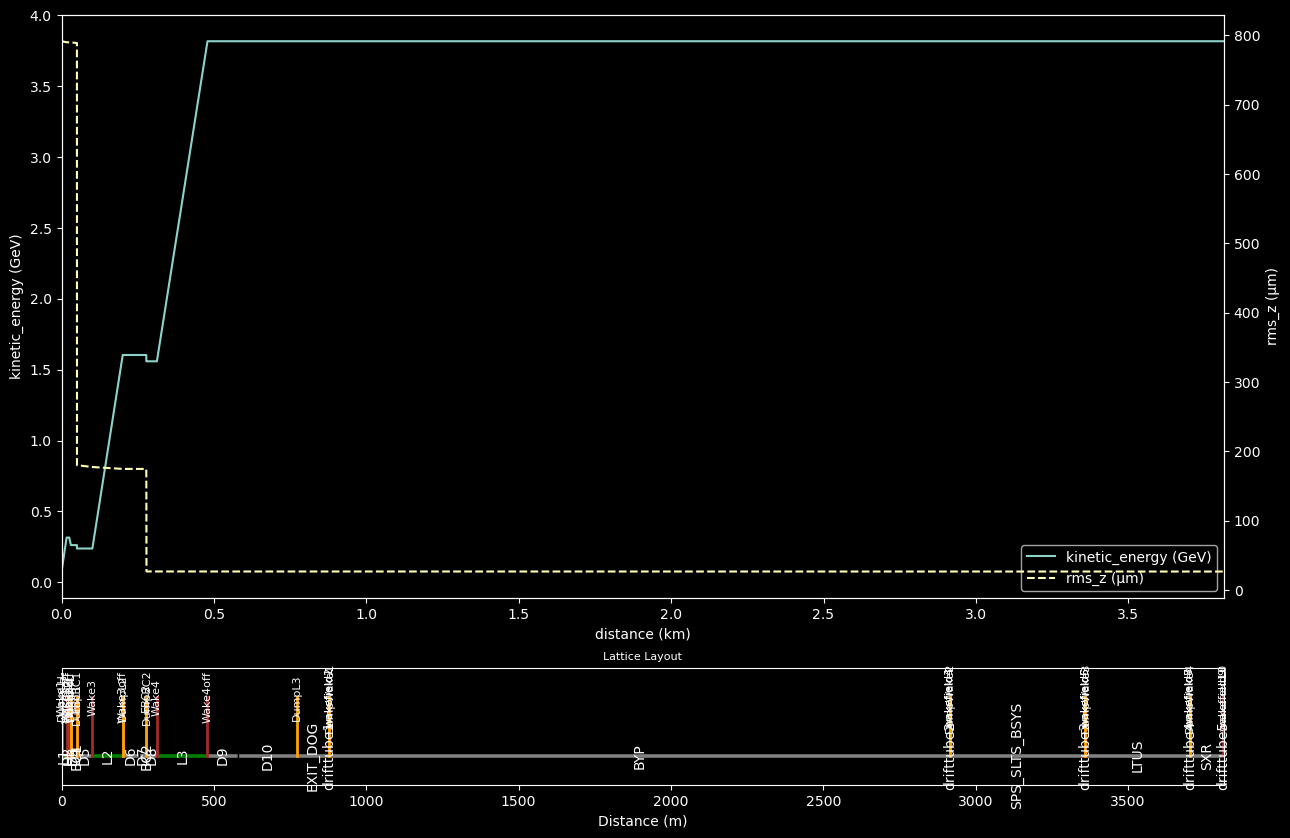

In [252]:
E.plot()

In [253]:
pg = E.output.particle_distributions[201].to_particlegroup()

In [254]:
pg['sigma_t']*1e15

np.float64(89.54119560404384)

In [255]:
pg['sigma_z']

np.float64(2.6843775122395096e-05)

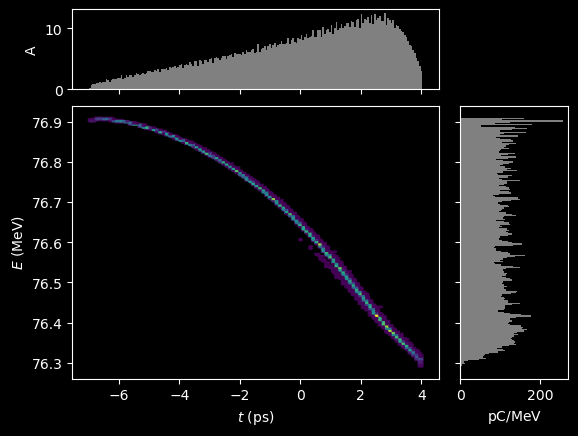

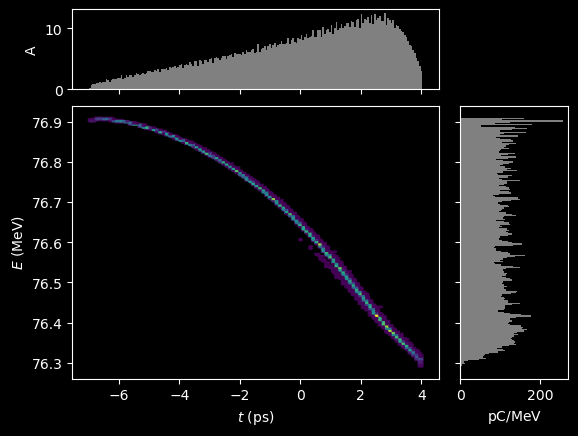

In [256]:
E.output.plot_distribution(file_id = 101, xkey="t", ykey="energy", bins = 200)

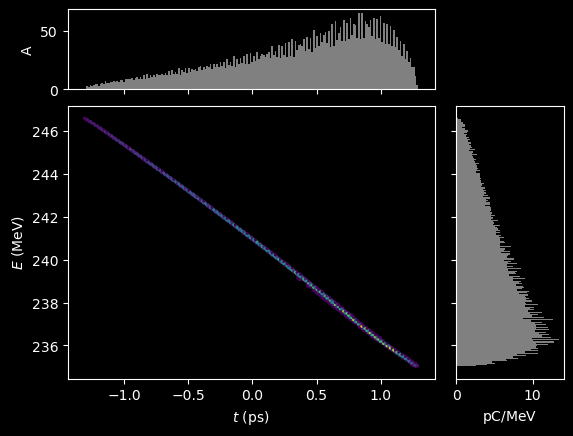

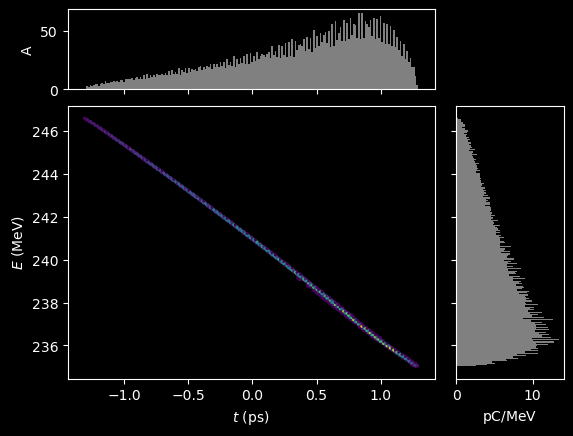

In [257]:
# after BC1
E.output.plot_distribution(file_id = 109, xkey="t", ykey="energy", bins = 200)

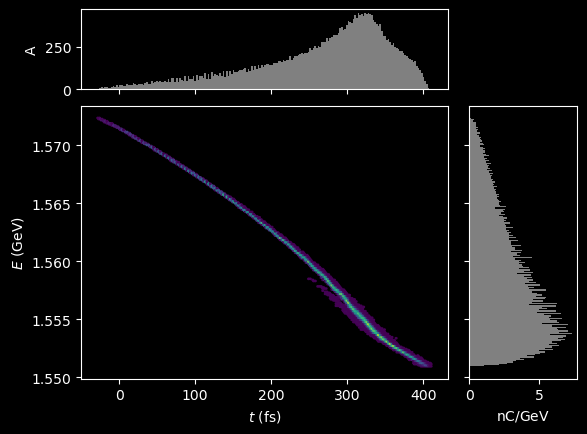

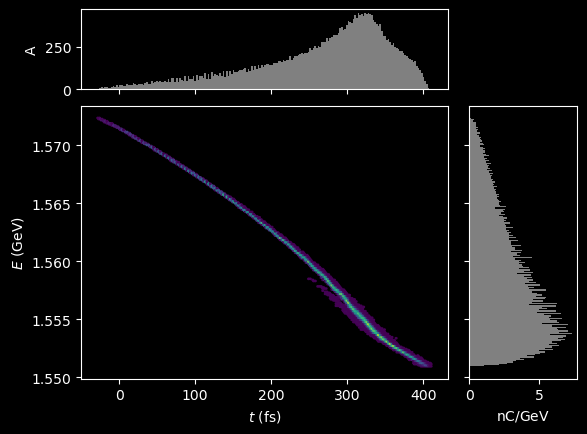

In [258]:
# after BC2
E.output.plot_distribution(file_id = 113, xkey="t", ykey="energy", bins = 200)

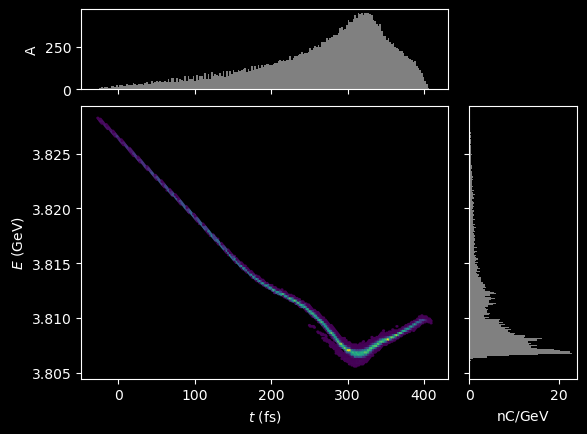

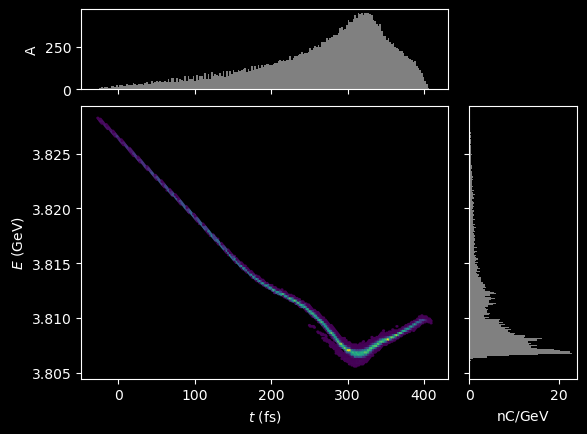

In [259]:
E.output.plot_distribution(file_id = 201, xkey="t", ykey="energy", bins = 200)

In [247]:
settings

{'Impact_particles': '/sdf/data/ad/ard/u/jytang/lume-belt-live/STCAV_data/particle-2025-05-17.h5',
 'BC1:angle': np.float64(0.10124165435817199),
 'BC2:angle': np.float64(0.046826045299326303),
 'L1:gradient': np.float64(15499981.172016071),
 'L1:phase_deg': np.float64(-24.989104158146233),
 'L2:gradient': np.float64(13691353.60931947),
 'L2:phase_deg': np.float64(-8.795710358284252),
 'L3:gradient': np.float64(13688564.945840476),
 'L3:phase_deg': np.float64(0.0),
 'HL:gradient': np.float64(10501381.052219367),
 'HL:phase_deg': np.float64(-169.1900675259798),
 'EBC1:energy_increment': np.float64(-13267782.755066246),
 'EBC2:energy_increment': np.float64(-26936422.27068901)}

In [248]:
pg.write(final_beam)

In [249]:
final_beam

'XTCAV_data/sim/LCLSII-snapshot-2025-05-17T09:52:23-07:00.h5'

In [436]:
E.input.lattice_lines

[WriteBeam(iwrite=102, sample=1, name='DumpLH'),
 DriftTube(length=74.9744159418, beam_radius=0.0003, name='D1'),
 Wakefield(length=0.0, multiplier=1.0, wake_function_file_id=41.0, switch=1.0, name='Wake1'),
 RFCavity(length=16.6, beam_radius=0.0003, gradient=np.float64(15319065.043921089), frequency=1300000000.0, phase_deg=np.float64(-25.831063278114264), name='L1'),
 Wakefield(length=0.0, multiplier=1.0, wake_function_file_id=41.0, switch=-1.0, name='Wake1off'),
 DriftTube(length=8.5305163742, beam_radius=0.0003, name='D2'),
 WriteBeam(iwrite=104, sample=1, name='DumpL1'),
 Wakefield(length=0.0, multiplier=1.0, wake_function_file_id=42.0, switch=1.0, name='Wake2'),
 RFCavity(length=5.53, beam_radius=0.0003, gradient=np.float64(9968950.461969564), frequency=3900000000.0, phase_deg=np.float64(-171.03313410549836), name='HL'),
 Wakefield(length=0.0, multiplier=1.0, wake_function_file_id=42.0, switch=-1.0, name='Wake2off'),
 WriteBeam(iwrite=106, sample=1, name='DumpHL'),
 DriftTube(leng

In [82]:
E.input.parameters

Parameters(np=200000, nz=128, zmin=-0.002981592, zmax=0.002211398, flagfwd=1, flagdist=100, Iavg=np.float64(0.07800000000000001), Ek=74489001.04999998, mass=511005.0, charge=np.float64(6.000000000000001e-11), freq=1300000000.0)